正在加载 DINO 与 Phi...


Using cache found in /home/ljc/.cache/torch/hub/facebookresearch_dino_main


[ok] Loaded Phi checkpoint with AttentionPhi(new) (strict-compatible).
正在计算 attention 与 Phi 映射...
MSE raw(Phi(DINO_MRI), DINO_CT): 3.249383
MSE norm(Phi(DINO_MRI), DINO_CT): 2.550745


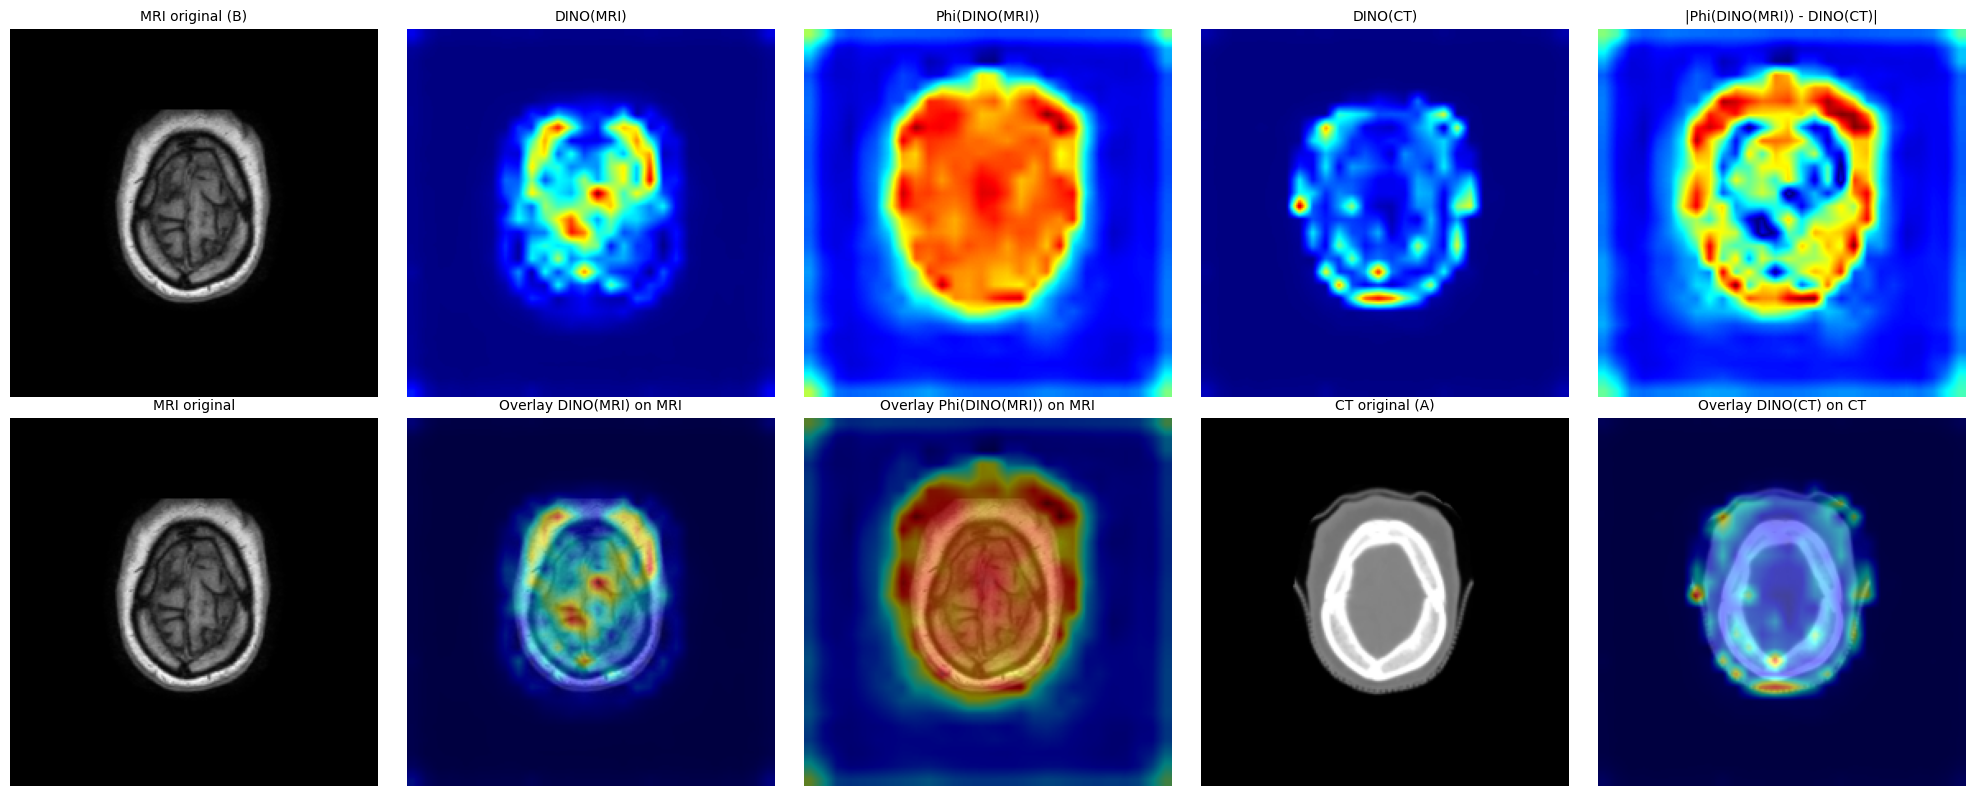

In [ ]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.transforms as transforms
from PIL import Image
import math
from pathlib import Path

from models.attention_phi import AttentionPhi


class LegacyAttentionPhi(nn.Module):
    """Backward-compatible Phi for old checkpoints (no attn/post_gate, shallower body)."""

    def __init__(self, in_channels=1, hidden_channels=32):
        super().__init__()
        self.head = nn.Sequential(
            nn.Conv2d(in_channels, hidden_channels, kernel_size=3, padding=1),
            nn.InstanceNorm2d(hidden_channels),
            nn.SiLU(inplace=True),
        )
        self.body = nn.Sequential(
            nn.Conv2d(hidden_channels, hidden_channels, kernel_size=3, padding=1),
            nn.InstanceNorm2d(hidden_channels),
            nn.SiLU(inplace=True),
            nn.Conv2d(hidden_channels, hidden_channels, kernel_size=3, padding=1),
            nn.InstanceNorm2d(hidden_channels),
            nn.SiLU(inplace=True),
        )
        self.tail = nn.Conv2d(hidden_channels, in_channels, kernel_size=3, padding=1)

    def forward(self, attn_map):
        feat = self.head(attn_map)
        feat = self.body(feat)
        delta = self.tail(feat)
        return attn_map + delta


class DinoLastBlockAttention:
    """Extract last-block CLS->patch attention map, aligned with the training pipeline."""

    def __init__(self, model):
        self.model = model
        self.last_attention = None
        self.hook_handle = None
        self._register_hook()

    def _register_hook(self):
        if not hasattr(self.model, "blocks") or len(self.model.blocks) == 0:
            raise RuntimeError("Model has no transformer blocks; cannot register DINO attention hook.")
        self.hook_handle = self.model.blocks[-1].attn.register_forward_hook(self._hook_fn)

    def _hook_fn(self, _module, _inputs, output):
        if isinstance(output, tuple):
            attn = output[1] if len(output) > 1 else output[0]
        else:
            attn = output
        if torch.is_tensor(attn):
            self.last_attention = attn

    def __call__(self, input_tensor):
        self.last_attention = None
        with torch.no_grad():
            _ = self.model(input_tensor)

        if self.last_attention is None:
            raise RuntimeError("Hook did not capture attention tensor.")

        attn = self.last_attention
        if attn.dim() == 4:
            # (B, heads, N, N) -> (B, N, N)
            attn = attn.mean(dim=1)
        if attn.dim() != 3:
            raise RuntimeError(f"Unexpected attention shape: {tuple(attn.shape)}")

        cls_to_patch = attn[:, 0, 1:]
        grid = int(math.sqrt(cls_to_patch.shape[-1]))
        if grid * grid != cls_to_patch.shape[-1]:
            raise RuntimeError(f"Token count {cls_to_patch.shape[-1]} does not form a square grid.")

        attn_map = cls_to_patch.view(input_tensor.shape[0], 1, grid, grid)
        attn_map = attn_map - attn_map.amin(dim=(2, 3), keepdim=True)
        attn_map = attn_map / attn_map.amax(dim=(2, 3), keepdim=True).clamp_min(1e-6)
        return attn_map

    def close(self):
        if self.hook_handle is not None:
            self.hook_handle.remove()
            self.hook_handle = None


def preprocess_image(image_path, image_size=224):
    transform = transforms.Compose([
        transforms.Resize((image_size, image_size)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ])
    img = Image.open(image_path).convert("RGB")
    x = transform(img).unsqueeze(0)
    img_resized = np.array(img.resize((image_size, image_size)))
    return x, img_resized


def _strip_module_prefix(state_dict):
    cleaned = {}
    for k, v in state_dict.items():
        cleaned[k[7:] if k.startswith("module.") else k] = v
    return cleaned


def load_best_phi(phi_path, device):
    ckpt = torch.load(phi_path, map_location=device)
    if not isinstance(ckpt, dict):
        raise RuntimeError("Unexpected checkpoint format for Phi.")

    ckpt = _strip_module_prefix(ckpt)
    if "head.0.weight" not in ckpt:
        keys_preview = list(ckpt.keys())[:10]
        raise RuntimeError(f"Cannot infer hidden channels from checkpoint keys: {keys_preview}")

    hidden_channels = int(ckpt["head.0.weight"].shape[0])

    # Auto-detect architecture variant from checkpoint keys.
    has_new_attn = any(k.startswith("attn.") for k in ckpt.keys())
    has_new_gate = any(k.startswith("post_gate.") for k in ckpt.keys())

    if has_new_attn or has_new_gate:
        phi = AttentionPhi(in_channels=1, hidden_channels=hidden_channels).to(device).eval()
        arch_name = "AttentionPhi(new)"
    else:
        phi = LegacyAttentionPhi(in_channels=1, hidden_channels=hidden_channels).to(device).eval()
        arch_name = "LegacyAttentionPhi(old)"

    incompatible = phi.load_state_dict(ckpt, strict=False)
    if len(incompatible.missing_keys) > 0 or len(incompatible.unexpected_keys) > 0:
        print(f"[warn] Loaded with key mismatch under {arch_name}.")
        if len(incompatible.missing_keys) > 0:
            print(f"  missing keys (first 10): {incompatible.missing_keys[:10]}")
        if len(incompatible.unexpected_keys) > 0:
            print(f"  unexpected keys (first 10): {incompatible.unexpected_keys[:10]}")
    else:
        print(f"[ok] Loaded Phi checkpoint with {arch_name} (strict-compatible).")

    return phi


def to_display_map(attn_map, out_size=224):
    """Convert (1,1,h,w) tensor to [0,1] numpy map resized to out_size."""
    m = attn_map.detach().squeeze().cpu().numpy()
    m = (m - m.min()) / (m.max() - m.min() + 1e-8)
    m = cv2.resize(m, (out_size, out_size), interpolation=cv2.INTER_LINEAR)
    return m


def make_heatmap_rgb(mask_01):
    heat = cv2.applyColorMap(np.uint8(255 * mask_01), cv2.COLORMAP_JET)
    return cv2.cvtColor(heat, cv2.COLOR_BGR2RGB)


def to_positive_distribution(map_2d, eps=1e-8):
    m = np.asarray(map_2d, dtype=np.float32)
    m = m - float(m.min())
    m = m + eps  # strictly positive
    m = m / float(m.sum())
    return m


def overlay_heatmap(rgb_img, heatmap_rgb, alpha=0.5):
    return np.float32(heatmap_rgb) / 255.0 * alpha + np.float32(rgb_img) / 255.0 * (1.0 - alpha)


def normalize_struct_features(feat, eps=1e-6):
    denom = feat.abs().mean(dim=(1, 2, 3), keepdim=True).clamp_min(eps)
    return feat / denom


def plot_grid(image_groups, titles, figsize=(18, 8)):
    rows = len(image_groups)
    cols = len(image_groups[0])
    fig, axes = plt.subplots(rows, cols, figsize=figsize)

    if rows == 1:
        axes = np.expand_dims(axes, axis=0)

    for r in range(rows):
        for c in range(cols):
            axes[r, c].imshow(image_groups[r][c])
            axes[r, c].set_title(titles[r][c], fontsize=10)
            axes[r, c].axis("off")

    plt.tight_layout()
    plt.show()


# --- Notebook 运行主逻辑 ---

# 1) 配置参数
IMG_PATH_CT = "/home/ljc/code/PaBoT-main/datasets/testA/1BA278_slice192.png"
IMG_PATH_MRI = "/home/ljc/code/PaBoT-main/datasets/testB/1BA278_slice192.png"
IMG_SIZE = 224

# 你的训练权重路径（按需修改）
BEST_PHI_PATH = "/home/ljc/code/PaBoT-main/checkpoints/dual_dino_phi_kl_cache_local5090/latest_net_Phi.pth"

# 2) 初始化模型
print("正在加载 DINO 与 Phi...")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
dino_model = torch.hub.load("facebookresearch/dino:main", "dino_vitb8").to(device).eval()
dino_attn = DinoLastBlockAttention(dino_model)

phi_path = Path(BEST_PHI_PATH)
if not phi_path.exists():
    raise FileNotFoundError(f"找不到 Phi 权重: {phi_path}")
phi_model = load_best_phi(str(phi_path), device=device)

# 3) 读取 CT / MRI 图像并提取 attention
print("正在计算 attention 与 Phi 映射...")
x_ct, ct_rgb = preprocess_image(IMG_PATH_CT, IMG_SIZE)
x_mri, mri_rgb = preprocess_image(IMG_PATH_MRI, IMG_SIZE)
x_ct = x_ct.to(device)
x_mri = x_mri.to(device)

with torch.no_grad():
    attn_ct = dino_attn(x_ct)               # DINO(CT)
    attn_mri = dino_attn(x_mri)             # DINO(MRI)
    phi_dino_mri_raw = phi_model(attn_mri)  # Phi(DINO(MRI)) raw
    phi_dino_mri = normalize_struct_features(phi_dino_mri_raw)  # Phi(DINO(MRI)) normalized

# 4) 计算数值指标：Phi(DINO_MRI) 与 DINO_CT
phi_mri_norm = phi_dino_mri
attn_ct_norm = normalize_struct_features(attn_ct)
mse_raw = F.mse_loss(phi_dino_mri_raw, attn_ct).item()
mse_norm = F.mse_loss(phi_mri_norm, attn_ct_norm).item()
print(f"MSE raw(Phi(DINO_MRI), DINO_CT): {mse_raw:.6f}")
print(f"MSE norm(Phi(DINO_MRI), DINO_CT): {mse_norm:.6f}")

# 5) 可视化（重点：DINO_MRI, Phi(DINO_MRI), DINO_CT）
map_ct_raw = to_display_map(attn_ct, out_size=IMG_SIZE)
map_mri_raw = to_display_map(attn_mri, out_size=IMG_SIZE)
map_phi_mri_raw = to_display_map(phi_dino_mri, out_size=IMG_SIZE)

# 先转成严格正值、总和为 1 的概率分布，再做上色
map_ct = to_positive_distribution(map_ct_raw)
map_mri = to_positive_distribution(map_mri_raw)
map_phi_mri = to_positive_distribution(map_phi_mri_raw)

shared_vmax = max(float(map_ct.max()), float(map_mri.max()), float(map_phi_mri.max()))
shared_vmax = max(shared_vmax, 1e-8)
map_ct_vis = np.clip(map_ct / shared_vmax, 0.0, 1.0)
map_mri_vis = np.clip(map_mri / shared_vmax, 0.0, 1.0)
map_phi_mri_vis = np.clip(map_phi_mri / shared_vmax, 0.0, 1.0)

map_err = np.abs(map_phi_mri - map_mri)
map_err = (map_err - map_err.min()) / (map_err.max() - map_err.min() + 1e-8)

heat_ct = make_heatmap_rgb(map_ct_vis)
heat_mri = make_heatmap_rgb(map_mri_vis)
heat_phi_mri = make_heatmap_rgb(map_phi_mri_vis)
heat_err = make_heatmap_rgb(map_err)

ov_ct = overlay_heatmap(ct_rgb, heat_ct, alpha=0.5)
ov_mri = overlay_heatmap(mri_rgb, heat_mri, alpha=0.5)
ov_phi_mri = overlay_heatmap(mri_rgb, heat_phi_mri, alpha=0.5)

images = [
    [mri_rgb, heat_mri, heat_phi_mri, heat_ct, heat_err],
    [mri_rgb, ov_mri, ov_phi_mri, ct_rgb, ov_ct],
]

titles = [
    [
        "MRI original (B)",
        "DINO(MRI)",
        "Phi(DINO(MRI))",
        "DINO(CT)",
        "|Phi(DINO(MRI)) - DINO(CT)|",
    ],
    [
        "MRI original",
        "Overlay DINO(MRI) on MRI",
        "Overlay Phi(DINO(MRI)) on MRI",
        "CT original (A)",
        "Overlay DINO(CT) on CT",
    ],
]

plot_grid(images, titles, figsize=(20, 8))
print(f"sum(DINO_MRI)={map_mri.sum():.6f}, min={map_mri.min():.6e}")
print(f"sum(Phi(DINO_MRI))={map_phi_mri.sum():.6f}, min={map_phi_mri.min():.6e}")
print(f"sum(DINO_CT)={map_ct.sum():.6f}, min={map_ct.min():.6e}")

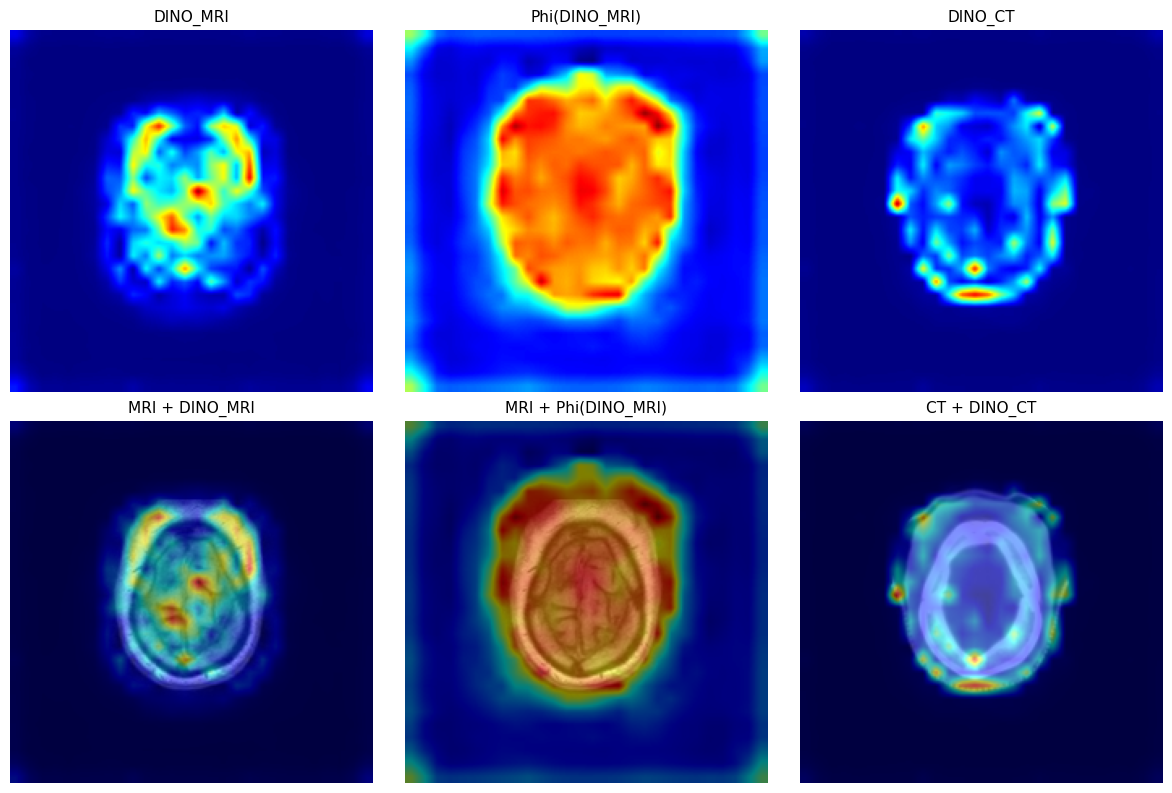

In [ ]:
# 极简 3x2 可视化：仅 DINO_MRI / Phi(DINO_MRI) / DINO_CT
required_vars = [
    "heat_mri", "heat_phi_mri", "heat_ct",
    "ov_mri", "ov_phi_mri", "ov_ct",
    "mri_rgb", "ct_rgb"
 ]
missing = [v for v in required_vars if v not in globals()]
if missing:
    raise RuntimeError(
        "请先运行第 1 个代码单元再运行本单元。缺失变量: " + ", ".join(missing)
    )

fig, axes = plt.subplots(2, 3, figsize=(12, 8))

# 第一行：纯热力图（DINO 与 Phi 使用同一色标）
axes[0, 0].imshow(heat_mri)
axes[0, 0].set_title("DINO_MRI", fontsize=11)
axes[0, 0].axis("off")

axes[0, 1].imshow(heat_phi_mri)
axes[0, 1].set_title("Phi(DINO_MRI)", fontsize=11)
axes[0, 1].axis("off")

axes[0, 2].imshow(heat_ct)
axes[0, 2].set_title("DINO_CT", fontsize=11)
axes[0, 2].axis("off")

# 第二行：对应叠加图（MRI / MRI / CT）
axes[1, 0].imshow(ov_mri)
axes[1, 0].set_title("MRI + DINO_MRI", fontsize=11)
axes[1, 0].axis("off")

axes[1, 1].imshow(ov_phi_mri)
axes[1, 1].set_title("MRI + Phi(DINO_MRI)", fontsize=11)
axes[1, 1].axis("off")

axes[1, 2].imshow(ov_ct)
axes[1, 2].set_title("CT + DINO_CT", fontsize=11)
axes[1, 2].axis("off")

plt.tight_layout()
plt.show()

CT total=7319, MRI total=7319, pair_base=7319
Using first 731/731 paired CT samples for attention mean (ratio=0.10)
  processed 200/731
  processed 400/731
  processed 600/731
  processed 731/731


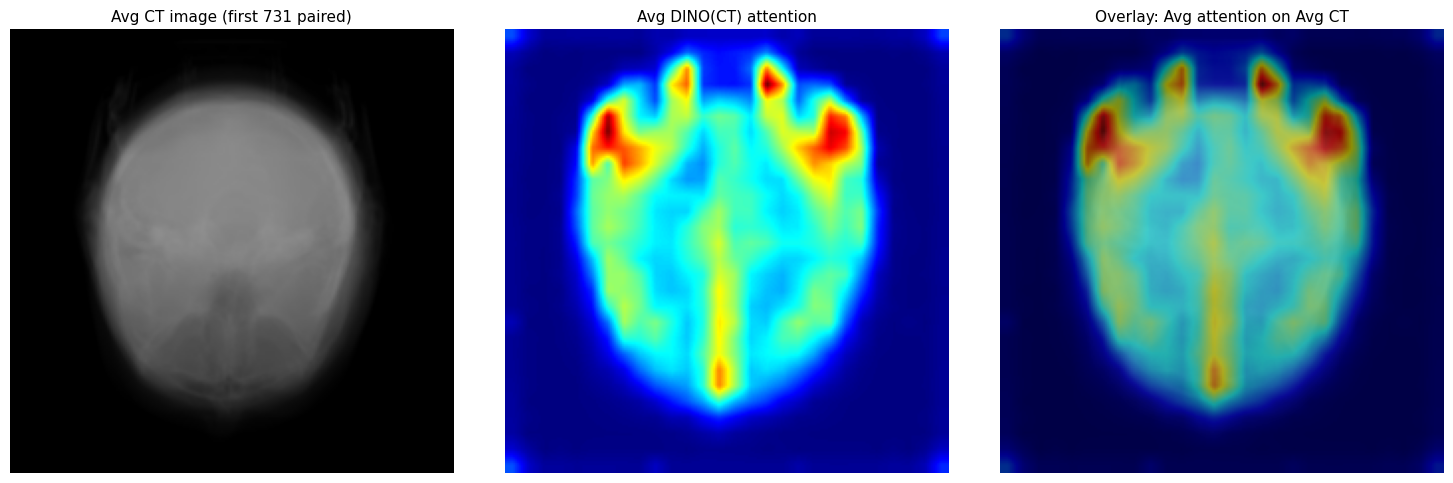

avg_attn_ct mean=0.208026, std=0.221595


In [ ]:
# 统计训练 Phi 使用的前 10% 配对数据中，CT 的 DINO attention 平均图
from pathlib import Path

# 可调参数（与训练时 controlled_pairing + paired_ratio 逻辑一致）
TRAIN_A_DIR = Path("/home/ljc/code/PaBoT-main/datasets/trainA")  # CT
TRAIN_B_DIR = Path("/home/ljc/code/PaBoT-main/datasets/trainB")  # MRI
PAIRED_RATIO = 0.10
MAX_SAMPLES = None   # 例如可设为 500 做快速检查；None 表示用全部 10%

if "dino_attn" not in globals() or "device" not in globals():
    raise RuntimeError("请先运行第 1 个代码单元，确保 dino_attn 和 device 已初始化。")

valid_exts = {".png", ".jpg", ".jpeg", ".bmp", ".tif", ".tiff", ".webp"}
ct_paths = sorted([p for p in TRAIN_A_DIR.iterdir() if p.suffix.lower() in valid_exts])
mri_paths = sorted([p for p in TRAIN_B_DIR.iterdir() if p.suffix.lower() in valid_exts])

if len(ct_paths) == 0 or len(mri_paths) == 0:
    raise RuntimeError("trainA/trainB 为空或路径不正确，请检查 TRAIN_A_DIR / TRAIN_B_DIR。")

pair_base_size = min(len(ct_paths), len(mri_paths))
paired_cutoff = max(0, min(pair_base_size, int(PAIRED_RATIO * pair_base_size)))

if paired_cutoff <= 0:
    raise RuntimeError(
        f"paired_cutoff={paired_cutoff}，无法计算。请增大 PAIRED_RATIO 或检查训练集大小。"
    )

n_use = paired_cutoff if MAX_SAMPLES is None else min(paired_cutoff, int(MAX_SAMPLES))
print(f"CT total={len(ct_paths)}, MRI total={len(mri_paths)}, pair_base={pair_base_size}")
print(f"Using first {n_use}/{paired_cutoff} paired CT samples for attention mean (ratio={PAIRED_RATIO:.2f})")

sum_attn = None
sum_ct_rgb = None

for i, p_ct in enumerate(ct_paths[:n_use], start=1):
    x_ct, ct_rgb = preprocess_image(str(p_ct), IMG_SIZE)
    x_ct = x_ct.to(device)
    with torch.no_grad():
        attn_ct_i = dino_attn(x_ct)  # (1,1,h,w), normalized to [0,1] in extractor

    map_ct_i = to_positive_distribution(to_display_map(attn_ct_i, out_size=IMG_SIZE))
    if sum_attn is None:
        sum_attn = map_ct_i.astype(np.float64)
        sum_ct_rgb = ct_rgb.astype(np.float64)
    else:
        sum_attn += map_ct_i
        sum_ct_rgb += ct_rgb

    if i % 200 == 0 or i == n_use:
        print(f"  processed {i}/{n_use}")

avg_attn_ct = (sum_attn / float(n_use)).astype(np.float32)
avg_attn_ct = to_positive_distribution(avg_attn_ct)
avg_ct_rgb = np.clip(sum_ct_rgb / float(n_use), 0, 255).astype(np.uint8)

avg_attn_heat = make_heatmap_rgb(avg_attn_ct)
avg_attn_overlay = overlay_heatmap(avg_ct_rgb, avg_attn_heat, alpha=0.55)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.8))
axes[0].imshow(avg_ct_rgb)
axes[0].set_title(f"Avg CT image (first {n_use} paired)", fontsize=11)
axes[0].axis("off")

axes[1].imshow(avg_attn_heat)
axes[1].set_title("Avg DINO(CT) attention", fontsize=11)
axes[1].axis("off")

axes[2].imshow(avg_attn_overlay)
axes[2].set_title("Overlay: Avg attention on Avg CT", fontsize=11)
axes[2].axis("off")

plt.tight_layout()
plt.show()

print(f"avg_attn_ct sum={float(avg_attn_ct.sum()):.6f}, min={float(avg_attn_ct.min()):.6e}, mean={float(avg_attn_ct.mean()):.6f}, std={float(avg_attn_ct.std()):.6f}")